# Task 1
Підготуйте дані.
* Використовуйте датасет MNIST із torchvision.datasets.
* Завантажте навчальну і тестову вибірки.
* Перетворіть зображення в тензори та нормалізуйте їх.
* Створіть DataLoader із батчем розміром 64.

In [1]:
import torch
from torchvision import datasets, transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [3]:
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

64


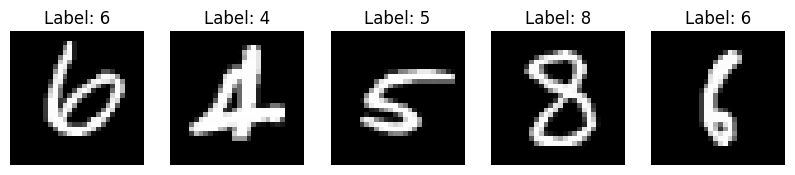

In [4]:
import matplotlib.pyplot as plt

train_iter = iter(train_loader)
images, labels = next(train_iter)
print(len(labels))

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')
plt.show()


# Task 2
Побудуйте просту згорткову нейронну мережу.
* Використовуйте шари:
    - Conv2d(1, 16, kernel_size=3);
    - ReLU();
    - MaxPool2d(2);
    - Flatten();
    - Linear(16 * 13 * 13, 10).
* Функція втрат — CrossEntropyLoss, оптимізатор — Adam(lr=0.001).
* Навчіть модель 10 епох.

In [5]:
import torch.nn as nn
import torch.optim as optim
class ConvNN(nn.Module):
    def __init__(self):
        super(ConvNN, self).__init__()
        self.conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = ConvNN()
loss_f = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
epochs = 10
losses = []
for epoch in range(epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f'Epoch: {epoch+1}, Loss: {total_loss}')

Epoch: 1, Loss: 24.577470482734498
Epoch: 2, Loss: 22.417079193226527
Epoch: 3, Loss: 20.397089328937
Epoch: 4, Loss: 17.923127200454473
Epoch: 5, Loss: 16.46332485496532
Epoch: 6, Loss: 14.451443209676654
Epoch: 7, Loss: 13.861869726562873
Epoch: 8, Loss: 12.400646144611528
Epoch: 9, Loss: 11.076842095892061
Epoch: 10, Loss: 10.390389143918583


# Task 3
Відстежуйте та візуалізуйте процес навчання.
* Виведіть втрати за епохами.
* Побудуйте графік залежності loss від епох.
* Збережіть модель у файл mnist_cnn.pth.

In [36]:
print(losses)

[24.577470482734498, 22.417079193226527, 20.397089328937, 17.923127200454473, 16.46332485496532, 14.451443209676654, 13.861869726562873, 12.400646144611528, 11.076842095892061, 10.390389143918583]


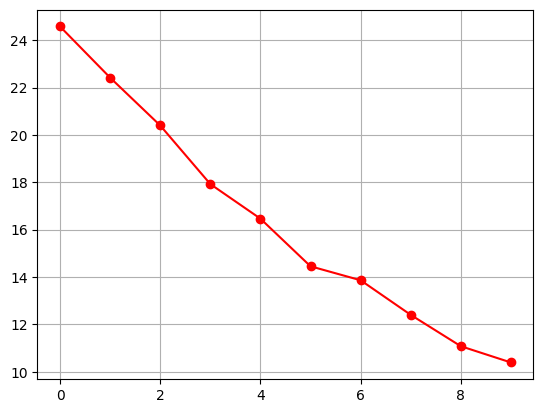

In [37]:
_, ax = plt.subplots()
ax.plot(losses, 'r-o')
plt.grid()
plt.show()

# Task 4
* Перевірте точність моделі на тестовій вибірці та оформіть результати:

In [38]:
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                mis.append({
                    'label': labels[i],
                    'predicted': predicted[i],
                    'image': images[i]
                })
print(len(mis))  

208


In [39]:
from IPython.display import Markdown as md

In [40]:
percent_accuracy = (correct / total) * 100
results_md = f"""
| Metric | Value |
|---|---|
| Accuracy | {percent_accuracy} |
| Loss | {(100 - percent_accuracy)} |
"""
md(results_md)


| Metric | Value |
|---|---|
| Accuracy | 97.92 |
| Loss | 2.0799999999999983 |


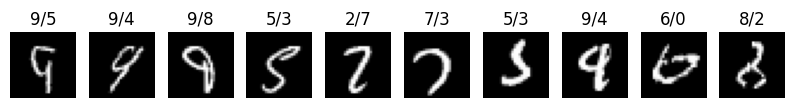

In [42]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(mis[i]['image'].squeeze(), cmap='gray')
    plt.title(f'{mis[i]['label']}/{mis[i]['predicted']}')
    plt.axis('off')
plt.show()